In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [3]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
]

In [4]:
RUN = ["3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    #keep_columns=keep_vars,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3


In [5]:
print("RecoLeadProton_dEdx_y_per_trklen" in rundata["mc"].columns)

True


In [6]:
run_combo = "Run"
for run in RUN:
    run_combo += run

Total candidate signal events: 75.86627903229048
After cuts:
Total signal events: 17.220186238698926
Total background events: 36.50548013119745
Total events: 53.72566636989637
sig + bkg = 53.72566636989637

Efficiency: 22.698076745492695
Purity: 32.05206636273154



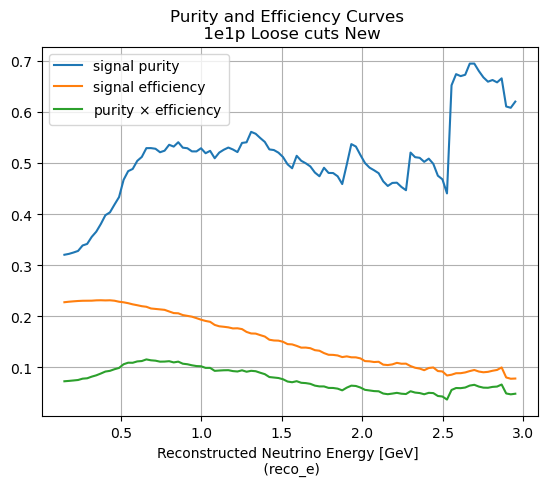

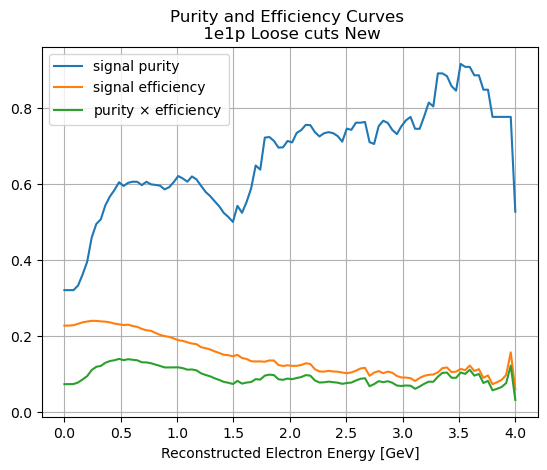

/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:51: RuntimeWarning: invalid value encountered in double_scalars
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:52: RuntimeWarning: invalid value encountered in double_scalars


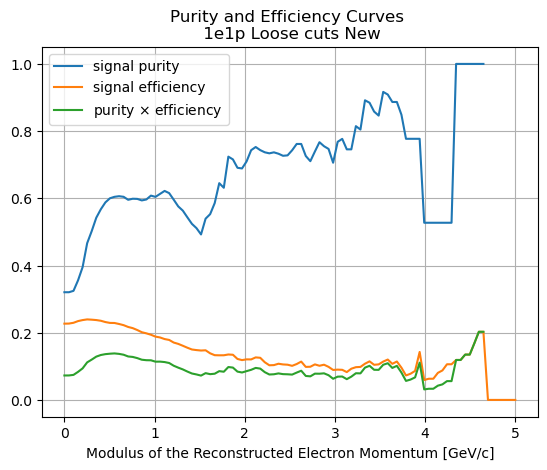

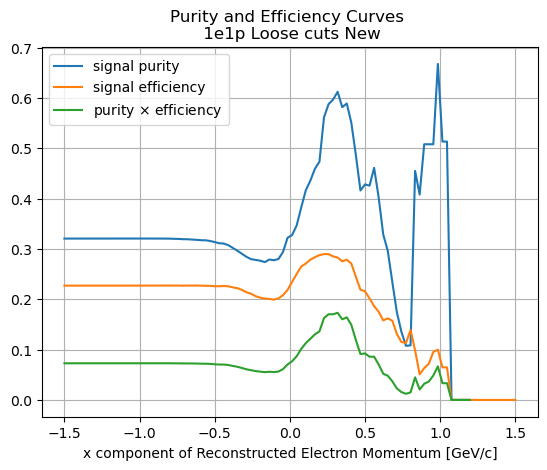

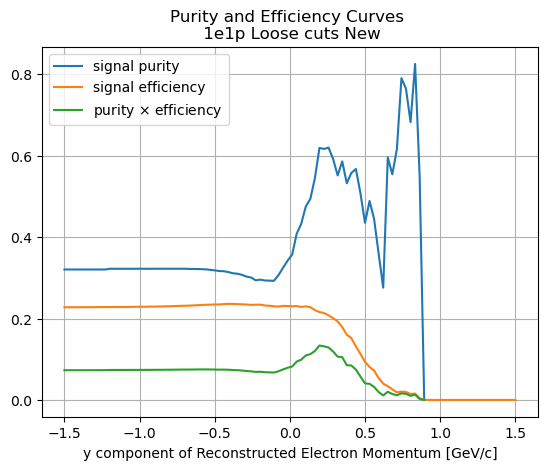

/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:50: RuntimeWarning: invalid value encountered in double_scalars


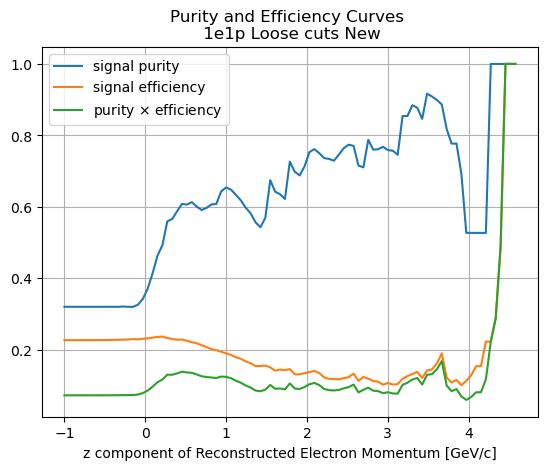

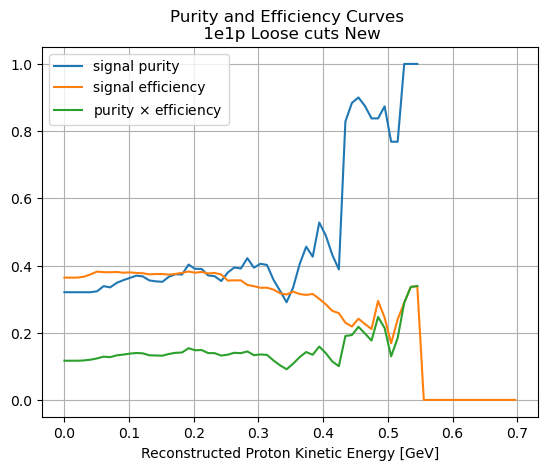

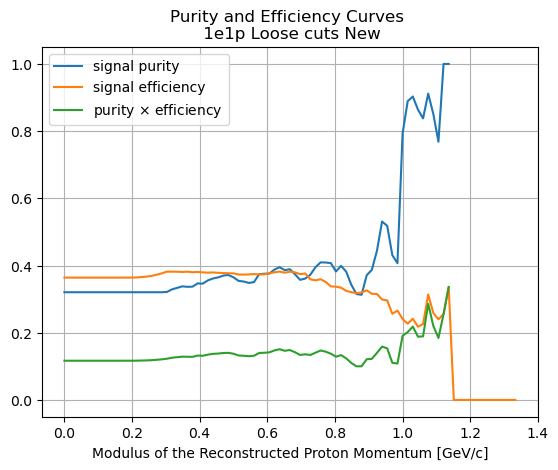

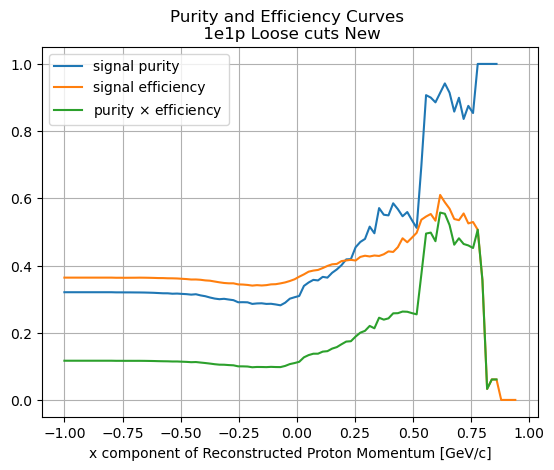

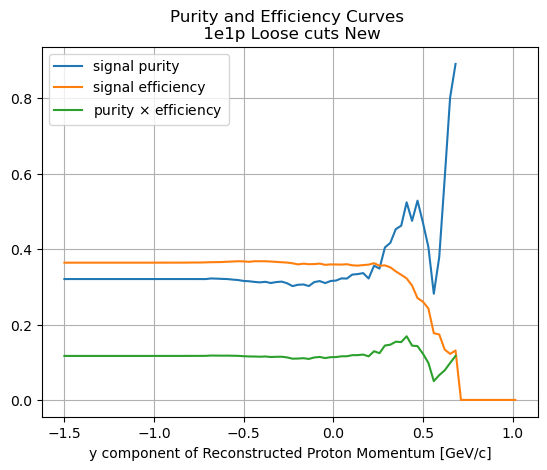

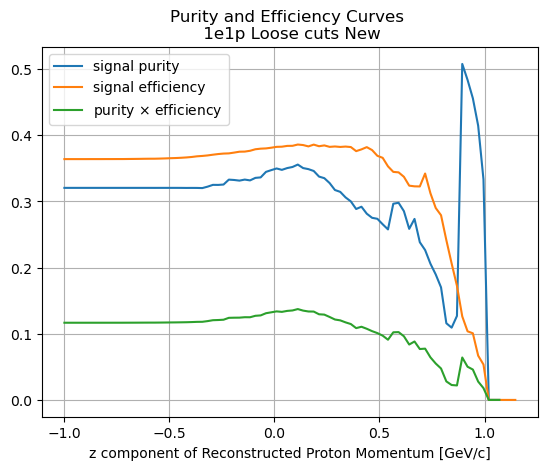

In [8]:
# Calculating efficiency and purity for TKI variables

from microfit import selections as sel

selection = "OnePL_new"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
sel_title = f"{sel.selection_categories[selection]['title']}"

# All available MC (plus EXT) events
all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])

all_sig = all_mc['category_1e1p'] == 12
tot_sig = np.sum(all_mc.loc[all_sig, 'weights'])
tot_bkg = np.sum(all_mc.loc[~all_sig, 'weights'])
print('Total candidate signal events:', tot_sig)

# Selected events - total prediction
sel_mc = all_mc.query(query, engine='python')

is_sig = sel_mc['category_1e1p'] == 12
sel_sig = np.sum(sel_mc.loc[is_sig, 'weights'])
sel_bkg = np.sum(sel_mc.loc[~is_sig, 'weights'])
sel_evt = np.sum(sel_mc['weights'])
print('After cuts:')
print('Total signal events:', sel_sig)
print('Total background events:', sel_bkg)
print('Total events:', sel_evt)
print('sig + bkg =', sel_sig+sel_bkg)
print()
efficiency = (sel_sig / tot_sig) * 100
purity = (sel_sig / sel_evt) * 100
print('Efficiency:', efficiency)
print('Purity:', purity)
print()

for binning_def in vdef.variables_1e1p:

    
    x_plot = np.linspace(binning_def[2][0], binning_def[2][1], 100)
    eff = []
    pur = []
    product = []
    
    for x in x_plot:
        sig_above = np.sum(sel_mc.loc[is_sig & (sel_mc[binning_def[0]] > x), 'weights'])
        bkg_above = np.sum(sel_mc.loc[~is_sig & (sel_mc[binning_def[0]] > x), 'weights'])
        tot_sig_above = np.sum(all_mc.loc[all_sig & (all_mc[binning_def[0]] > x), 'weights'])
        
        eff.append(sig_above/tot_sig_above)
        pur.append(sig_above/(sig_above + bkg_above))
        product.append((sig_above/tot_sig_above) * (sig_above/(sig_above + bkg_above)))
        
    plt.plot(x_plot, pur, label='signal purity')
    plt.plot(x_plot, eff, label='signal efficiency')
    plt.plot(x_plot, product, label='purity $\\times$ efficiency')
    plt.legend()
    plt.grid()
    plt.xlabel(binning_def[3])
    plt.title(f'Purity and Efficiency Curves \n {sel_title}')
    #plt.savefig(f'plots/pur_eff/metrics_{preselection}_{selection}_{binning_def[0]}_{run_combo}.pdf', bbox_inches='tight')
    #plt.savefig(f'plots/pur_eff/metrics_{preselection}_{selection}_{binning_def[0]}_{run_combo}.png', bbox_inches='tight')
    plt.show()

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])


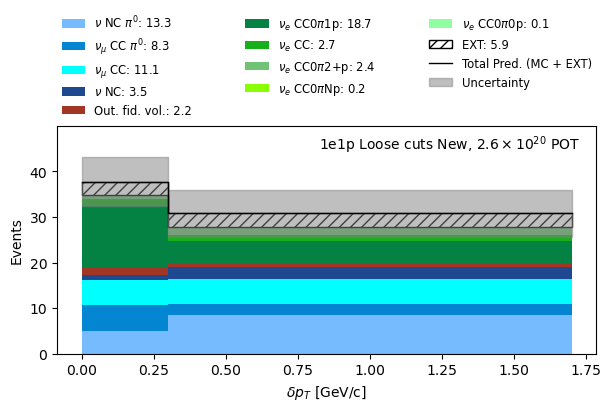

('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


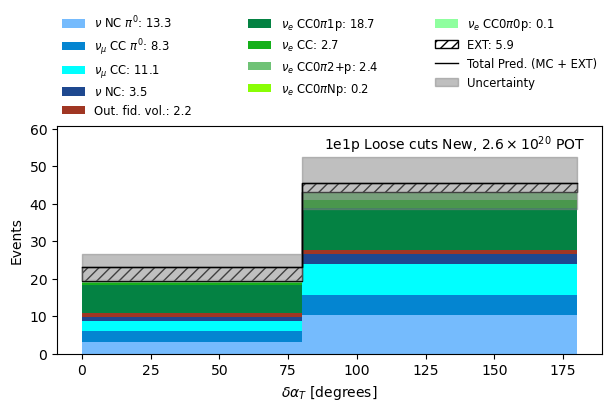

('RecoPN', None, None, '$p_n$ [GeV/c]', False, None, [0, 0.3, 1.7])


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


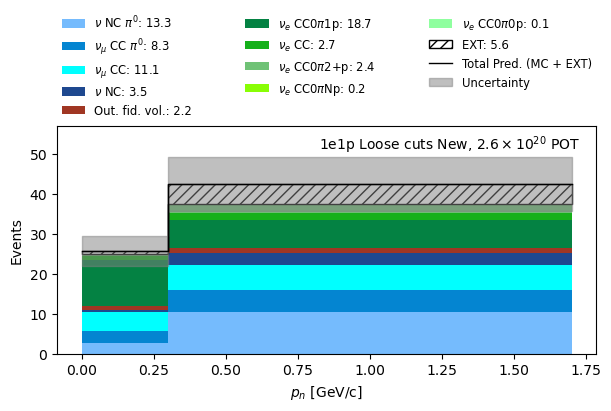

('RecoAlpha3D', None, None, '$\\alpha_{3D}$ [degrees]', False, None, [0, 90, 180])


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


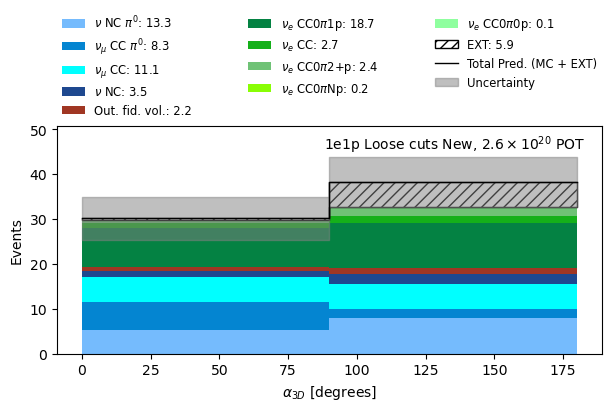

('RecoDeltaPT', 10, (0, 1.7), '$\\delta p_T$ [GeV/c]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


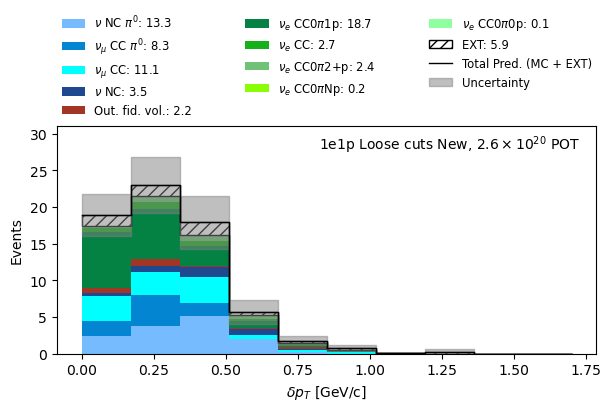

('RecoDeltaAlphaT', 10, (0, 180), '$\\delta \\alpha_T$ [degrees]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


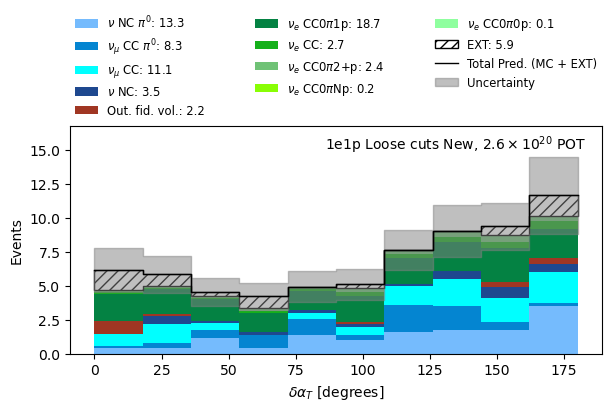

('RecoPN', 10, (0, 1.7), '$p_n$ [GeV/c]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


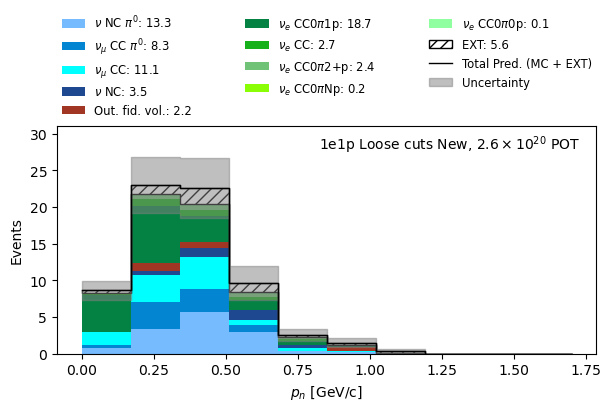

('RecoAlpha3D', 10, (0, 180), '$\\alpha_{3D}$ [degrees]')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


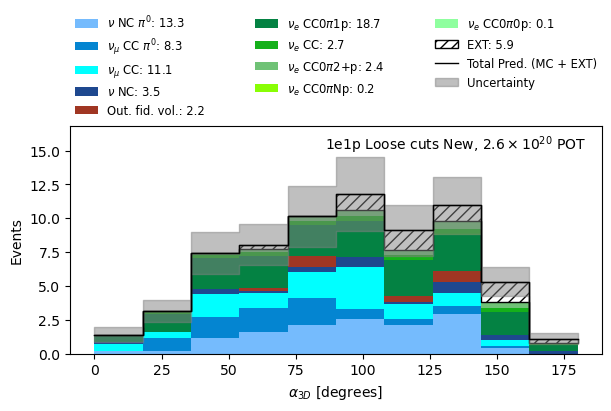

In [14]:
selection = "OnePL_new"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def) #[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="category_1e1p",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )
    
    plt.savefig(f'plots/investigation/categoryfixed_topo_{preselection}_{selection}_{binning_def[0]}_{run_combo}.pdf', bbox_inches='tight')
    plt.show()

#     axes2 = plotter.plot(
#         category_column="interaction",
#         include_multisim_errors=True,
#         add_ext_error_floor=False,
#         show_data_mc_ratio=False,
#         show_chi_square=False,
#     )

#     #plt.savefig(f'plots/reco_study/int_{preselection}_{selection}_{binning_def[0]}_{run_combo}.pdf', bbox_inches='tight')
#     plt.show()

## Distributions with variable bin sizes 

The function from_config has the following signature:

@classmethod
    def from_config(
        cls,
        variable: str,
        n_bins: Optional[int],
        limits: Optional[Tuple[float, float]],
        variable_tex: Optional[str] = None,
        is_log: bool = False,
        label: Optional[str] = None,
        bin_edges: Optional[Union[np.ndarray, List[float]]] = None,
        **kwargs,
    ):
        """Create a Binning object from a typical binning configuration

        Parameters:
        -----------
        variable : str
            Name of the variable being binned
        n_bins : int, optional
            Real of bins. If not provided, then bin_edges must be provided.
        limits : tuple, optional
            Tuple of lower and upper limits. If not provided, then bin_edges must be provided.
        variable_tex : str, optional
            Label for the binned variable. This will be used to label the x-axis in plots.
        is_log : bool, optional
            Whether the binning is logarithmic or not (default is False)
        label : str, optional
            Label of the binning. In a multi-dimensional binning, this should be
            a unique key.
        bin_edges : np.ndarray, optional
            Array of bin edges. If this is provided, the n_bins and limits are ignored.

        Returns:
        --------
        Binning
            A Binning object with the specified bounds
        """
        
so what you need to do is to pass None for n_bins and limits. And pass bin_edges instead.

You would need to define the variable as

("RecoDeltaPT", None, None, "delta p_T", False, None, [0.0, 0.3, 2.0])

and then change the line so that it takes the entirety of the binning_def

binning = hist.Binning.from_config(*binning_def)

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 2])


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


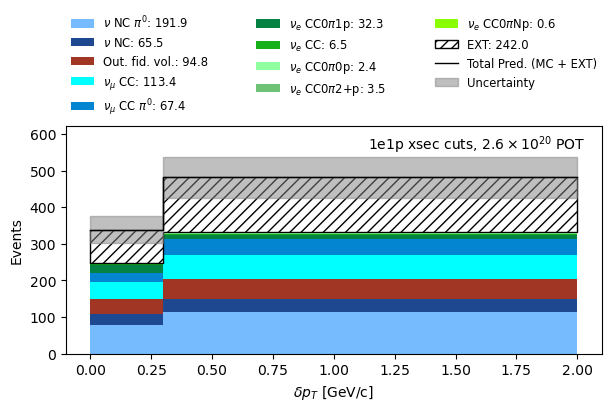

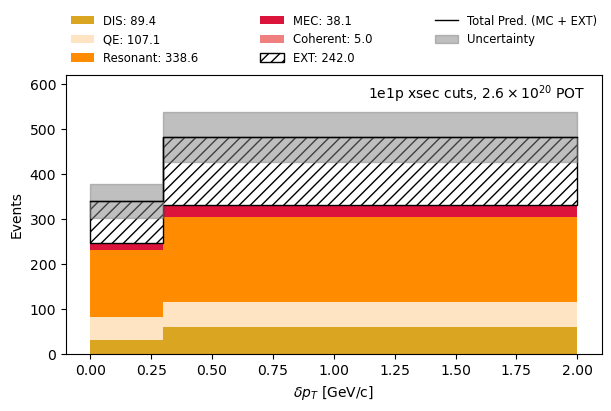

('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])


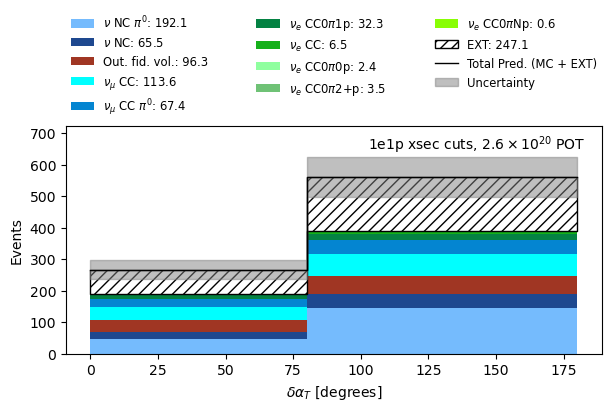

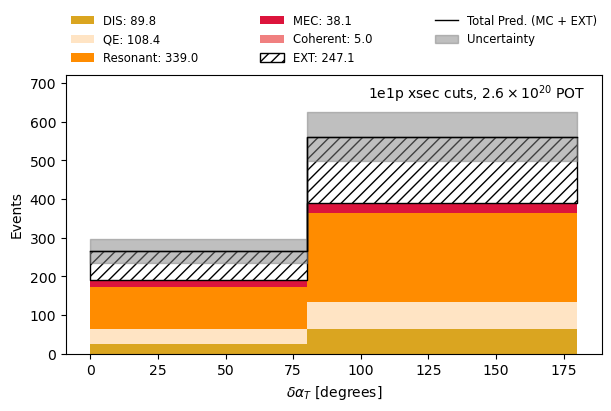

In [3]:
selection = "OnePL_new"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def)
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="category_1e1p",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )
    
    #plt.savefig(f'plots/reco_study/topo_{preselection}_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

    axes2 = plotter.plot(
        category_column="interaction",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )

    #plt.savefig(f'plots/reco_study/int_{preselection}_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

In [8]:
print(len(rundata["mc"]["pfp_generation_v"][876]))
print(len(rundata["mc"]["trk_trunk_dEdx_y_v"][876]))
rundata["mc"].loc[:,("pfp_generation_v", "trk_trunk_dEdx_y_v", "RecoLeadProton_trk_trunk_dEdx_y", "longest_trk_trunk_dEdx_y")].head(20)

4
4


,pfp_generation_v,trk_trunk_dEdx_y_v,RecoLeadProton_trk_trunk_dEdx_y,longest_trk_trunk_dEdx_y
entry,,,,
0,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]","[2.1169596, 2.4381227, 0.4394421, 2.553928, 4....",4.008846e+00,2.116960
1,"[2, 2, 2, 2, 2, 2, 2]","[5.912517, 2.5814807, 5.2084146, -3.4028235e+3...",5.208415e+00,5.912517
2,"[2, 2, 2, 2, 2]","[2.1362357, 2.1475108, -3.4028235e+38, -3.4028...",NaN,2.147511
3,"[2, 2]","[2.4138863, 6.370572]",NaN,2.413886
4,"[2, 2, 2]","[3.5469575, -3.4028235e+38, 13.305182]",1.330518e+01,3.546957
5,"[2, 3]","[1.8478818, 4.042985]",NaN,1.847882
7,[2],[4.8726687],NaN,4.872669
8,"[2, 2]","[5.093401, -3.4028235e+38]",NaN,5.093401
9,"[2, 3, 2, 2]","[2.0194507, 21.763098, 1.883265, 4.5800447]",4.580045e+00,2.019451
